# Train/Test Splitting

To test our models, we need to see how they do on unseen instances. To achieve this, we divide our data into a training set and a testing set. We only train our data on the training set, that way we can assess how well it does on the testing set.

How should we split the dataset?

## Method One: Holdout method
- "hold out" some instances for testing
    - Train on the remaining instances
- Typically use a standard "split" or percentage holdout
    - 2:1 split: holdout 1/3 for testing, train on remaining 2/3
    - 25% holdout: holdout 25% for testing, train on remaining 75%
        - Sci-kit learn default for train_test_split()


In [20]:
import pandas as pd
df = pd.read_csv("../shirt_sizes_long.csv")
X = df.drop(["t-shirt size"], axis="columns")
y = df["t-shirt size"]
print(X)
print(y)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X) # fitting it will determine the minimum and maximum values for each feature

X_scaled = scaler.transform(X)

    height(cm)  weight(kg)
0          158          58
1          158          59
2          158          63
3          160          59
4          160          60
5          163          60
6          163          61
7          160          64
8          163          64
9          165          61
10         165          62
11         165          65
12         168          62
13         168          63
14         168          66
15         170          63
16         170          64
17         170          68
0     M
1     M
2     M
3     M
4     M
5     M
6     M
7     L
8     L
9     L
10    L
11    L
12    L
13    L
14    L
15    L
16    L
17    L
Name: t-shirt size, dtype: object


In [21]:
from sklearn.model_selection import train_test_split

# shuffles by default
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=0, stratify=y)
print(X_train)
print(y_train)

[[0.58333333 0.3       ]
 [1.         1.        ]
 [0.83333333 0.5       ]
 [0.41666667 0.2       ]
 [0.58333333 0.7       ]
 [0.         0.5       ]
 [0.         0.1       ]
 [0.41666667 0.6       ]
 [1.         0.6       ]
 [0.16666667 0.1       ]
 [0.16666667 0.2       ]
 [1.         0.5       ]
 [0.83333333 0.8       ]]
9     L
17    L
13    L
5     M
11    L
2     M
1     M
8     L
16    L
3     M
4     M
15    L
14    L
Name: t-shirt size, dtype: object


In [22]:
print(X_test)
print(y_test)

[[0.83333333 0.4       ]
 [0.41666667 0.3       ]
 [0.16666667 0.6       ]
 [0.         0.        ]
 [0.58333333 0.4       ]]
12    L
6     M
7     L
0     M
10    L
Name: t-shirt size, dtype: object


In [23]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_clf.fit(X_train, y_train)
y_predicted = knn_clf.predict(X_test)
print(y_predicted)

['L' 'M' 'M' 'M' 'L']


In [24]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_predicted)
print(f"accuracy: {acc}")

# Other way to get accuracy
acc = knn_clf.score(X_test, y_test)
print("accuracy:", acc)

accuracy: 0.8
accuracy: 0.8


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predicted)
print(cm)

[[2 1]
 [0 2]]


In [26]:
# Can a decision tree do better? 
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier()

# task: take it from here!

tree_clf.fit(X_train, y_train)
y_predicted = tree_clf.predict(X_test)
tree_acc = accuracy_score(y_test, y_predicted)
print(f"tree accuracy: {tree_acc}")
tree_cm = confusion_matrix(y_test, y_predicted)
print(tree_cm)

tree accuracy: 1.0
[[3 0]
 [0 2]]


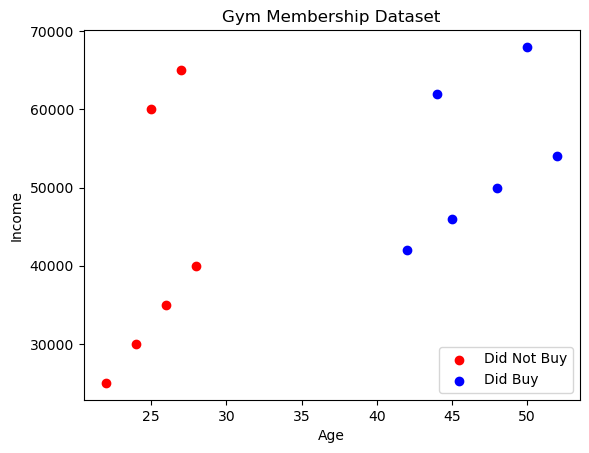

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV (make sure it's in the same directory)
df = pd.read_csv("../gym_members.csv")

# Split by label
did_not_buy = df[df["buys_premium_membership"] == 0]
did_buy = df[df["buys_premium_membership"] == 1]

# Scatter plot
plt.figure()

plt.scatter(did_not_buy["age"], did_not_buy["income"], label="Did Not Buy", color="red")
plt.scatter(did_buy["age"], did_buy["income"], label="Did Buy", color="blue")

# Labels + legend
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Gym Membership Dataset")
plt.legend()

plt.show()

In [29]:
X = df.drop(["buys_premium_membership"], axis="columns")
y = df["buys_premium_membership"]
print(X)
print(y)
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()

# scaler.fit(X) # fitting it will determine the minimum and maximum values for each feature

# X_scaled = scaler.transform(X)

    age  income
0    22   25000
1    24   30000
2    26   35000
3    28   40000
4    42   42000
5    45   46000
6    48   50000
7    52   54000
8    25   60000
9    27   65000
10   44   62000
11   50   68000
0     0
1     0
2     0
3     0
4     1
5     1
6     1
7     1
8     0
9     0
10    1
11    1
Name: buys_premium_membership, dtype: int64


In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=3, metric="euclidean")

# builds/trains
knn_clf.fit(X, y)

# predict
y_predicted = knn_clf.predict([[70, 20000]])
print(y_predicted)


[0]


/home/dom/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
